# Zero Interest Policy and the Tech Job Boom


Low interest rates (2010-2022) drove massive capital into venture funding → startups hired aggressively → tech salaries surged → bubble dynamics formed → rate hikes triggered correction.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import Request, urlopen
import io


In [2]:
df_fed = pd.read_csv('FEDFUNDS.csv')
df_tech = pd.read_csv('CES6054150001.csv')

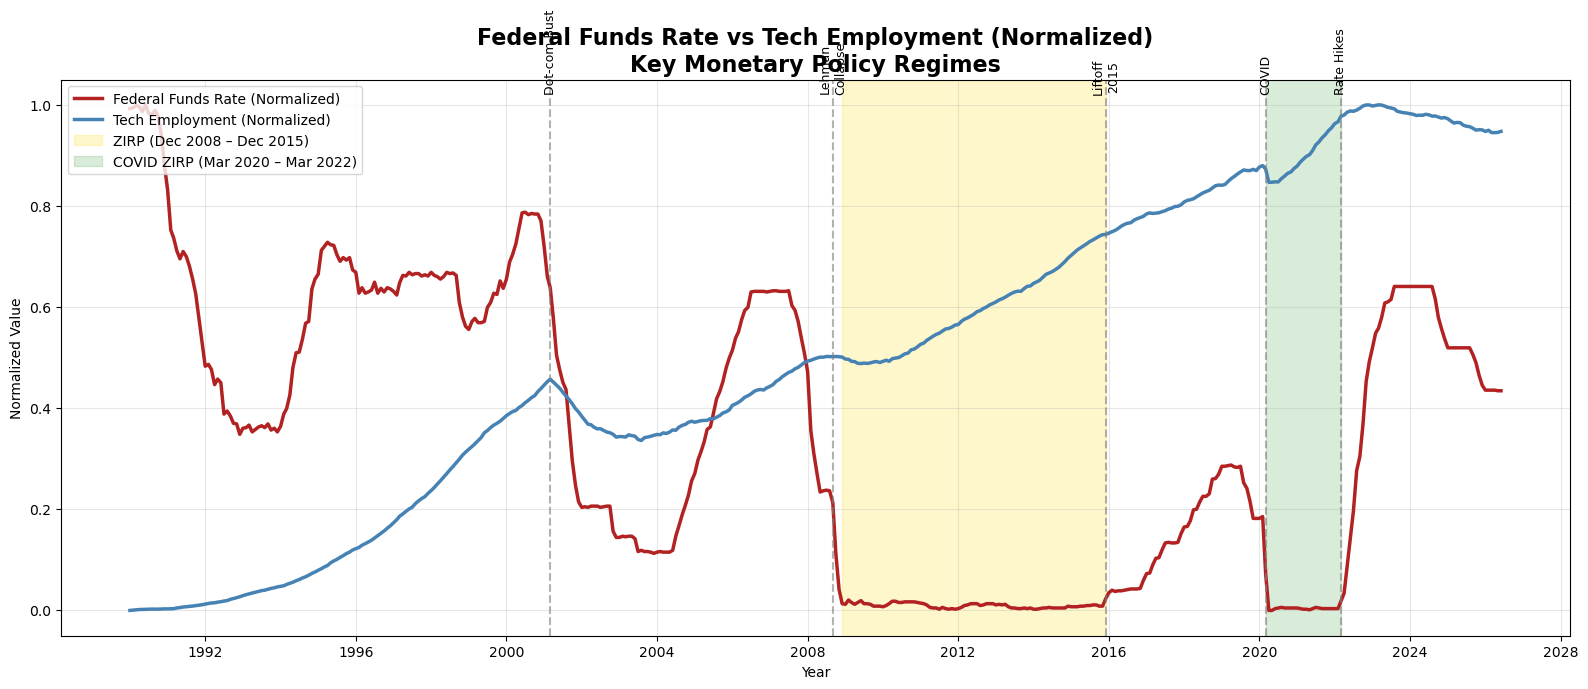

In [3]:
df_fed["observation_date"] = pd.to_datetime(df_fed["observation_date"])
df_tech["observation_date"] = pd.to_datetime(df_tech["observation_date"])

df = pd.merge(
    df_fed,
    df_tech,
    on="observation_date",
    how="inner"
)

df["Fed Funds Rate"] = (
    (df["FEDFUNDS"] - df["FEDFUNDS"].min()) /
    (df["FEDFUNDS"].max() - df["FEDFUNDS"].min())
)

df["Tech Employment"] = (
    (df["CES6054150001"] - df["CES6054150001"].min()) /
    (df["CES6054150001"].max() - df["CES6054150001"].min())
)

# Plot
plt.figure(figsize=(16,7))

plt.plot(
    df["observation_date"],
    df["Fed Funds Rate"],
    linewidth=2.5,
    color="firebrick",
    label="Federal Funds Rate (Normalized)"
)

plt.plot(
    df["observation_date"],
    df["Tech Employment"],
    linewidth=2.5,
    color="steelblue",
    label="Tech Employment (Normalized)"
)


plt.axvspan(
    pd.Timestamp("2008-12-01"),
    pd.Timestamp("2015-12-01"),
    color="gold",
    alpha=0.20,
    label="ZIRP (Dec 2008 – Dec 2015)"
)


plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2022-03-01"),
    color="green",
    alpha=0.15,
    label="COVID ZIRP (Mar 2020 – Mar 2022)"
)

# ----------------------------
# Key Events
# ----------------------------

events = {
    "Dot-com Bust": "2001-03-01",
    "Lehman\nCollapse": "2008-09-01",
    "Liftoff\n2015": "2015-12-01",
    "COVID": "2020-03-01",
    "Rate Hikes": "2022-03-01",
}

for label, date in events.items():
    d = pd.Timestamp(date)
    plt.axvline(d, color="gray", linestyle="--", alpha=0.6)
    plt.text(
        d,
        1.02,
        label,
        rotation=90,
        fontsize=9,
        ha="center",
        va="bottom"
    )

plt.title(
    "Federal Funds Rate vs Tech Employment (Normalized)\n"
    "Key Monetary Policy Regimes",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.grid(True, alpha=0.3)

plt.legend(
    loc="upper left",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()